### Overview

The [WaterDetect algorithm](https://github.com/cordmaur/WaterDetect) uses unsupervised clustering on water-sensitive spectral indices to automatically detect open water bodies from satellite imagery — without any labeled training data.

In this notebook we adapt the WaterDetect workflow for a cloud-native Python stack. We start from the multiband composite prepared in the previous section and run a K-Means clustering on water-sensitive spectral indices and Identify the water cluster as the one with the highest mean MNDWI.

### Setup

Determine our runtime environment.


In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install rioxarray dask['distributed'] scikit-learn

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask.array as da
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os
import rioxarray as rxr
import xarray as xr
from sklearn.cluster import KMeans

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Load Multiband Composite

Load the multiband composite saved by the previous notebook in this section `01_preparing_composites.ipynb`. The composite contains 13 bands: 6 raw spectral bands (red, green, blue, nir, swir16, swir22), 5 precomputed indices (ndvi, ndbi, bsi, mndwi, ndwi) and 2 bands derived from a DEM (elevation, slope).

In [ ]:
multiband_composite_path = os.path.join(data_folder, 'multiband_composite.tif')
if not os.path.exists(multiband_composite_path):
    print(f'Composite file not found at {multiband_composite_path}.',
          'Using default composite.')
    multiband_composite_path = (
        'https://storage.googleapis.com/spatialthoughts-public-data'
        '/python-remote-sensing/multiband_composite.tif')

band_names = ['red', 'green', 'blue', 'nir', 'swir16', 'swir22',
              'ndvi', 'ndbi', 'bsi', 'mndwi', 'ndwi', 'elevation', 'slope']
composite_da = rxr.open_rasterio(
    multiband_composite_path,
    masked=True,
    chunks={'x': 1024, 'y': 1024},
)
composite_da = composite_da.assign_coords(band=band_names)
composite = composite_da.to_dataset('band')
composite

### Load Area of Interest

Read the file containing the city boundary.

In [ ]:
aoi_filepath = os.path.join(data_folder, 'aoi.geojson')

if not os.path.exists(aoi_filepath):
    print(f'AOI file not found at {aoi_filepath}. Using default AOI.')
    aoi_filepath = ('https://storage.googleapis.com/spatialthoughts-public-data'
                    '/python-remote-sensing/aoi.geojson')

aoi_gdf = gpd.read_file(aoi_filepath)
geometry = aoi_gdf.geometry.union_all()
geometry

### Prepare WaterDetect Indices

The WaterDetect algorithm uses a three-band stack of water-sensitive indices as input to the clusterer.

- MNDWI: `(Green − SWIR1) / (Green + SWIR1)`
- NDWI: `(Green − NIR) / (Green + NIR)`
- MIR2:  `SWIR2`

NDWI and MNDWI are already available in the loaded composite. We add MIR2 as an alias for the SWIR2 band.


In [ ]:
composite['mir2'] = composite['swir22']

Water has high NDWI and MNDWI values and low MIR2 reflectance, making this combination highly discriminative. Other band combinations are described in the [WaterDetect configuration reference](https://github.com/cordmaur/WaterDetect/blob/master/WaterDetect.ini).

In [ ]:
clustering_bands = ['ndwi', 'mndwi', 'mir2']
#clustering_bands = ['ndwi', 'mndwi', 'nir']

### Unsupervised Clustering

We sample pixels from the three-band index stack and train a K-Means clusterer. Here we use scikit-learn's `KMeans` with a fixed `n_clusters`. Adjust this value if water bodies are split across multiple clusters or merged with other land cover types.

First, we extract all valid (non-NaN) pixels and draw a random sample to train on.

In [ ]:
# Convert the feature stack to a Dask array
feature_da = composite[clustering_bands].to_array('band')
feature_da = feature_da.chunk({'band': -1, 'y': 1024, 'x': 1024})
feature_da

In [ ]:
sample_size = 1000

# Stack spatial dims into a single point dimension (lazy, known size)
stacked = feature_da.stack(point=['y', 'x'])

# Oversample to account for NaN pixels at the data boundary
random_generator = np.random.default_rng(seed=42)
random_indices = random_generator.choice(
    len(stacked.point), size=sample_size * 2, replace=False)
random_sample = stacked.isel(point=random_indices)

In [ ]:
%%time
random_sample = random_sample.compute()

In [ ]:
random_sample

Scikit-Learn requires a 2D array of values. We transform the samples into pairs of band values, i.e. [[band1_val, band2_val, band3_val], [...]]. We then remove the null values and get our training set.

In [ ]:
transposed = random_sample.T.astype(np.float64)  # (n, 3)
valid = ~np.isnan(transposed).any(axis=1)
sample = transposed[valid][:sample_size]
sample

Train a clusterer. We use the [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) clusterer.

In [ ]:
n_clusters = 4

model = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
model.fit(sample)
print(f'Trained KMeans with {n_clusters} clusters')

Test the clusterer with some values.

In [ ]:
model.predict(np.array([
    [-0.21984932, -0.34398526,  0.2298],
    [-0.6138097 , -0.49620321,  0.07855 ]
  ]))

Apply the trained clusterer to all pixels using [`map_blocks`](https://docs.dask.org/en/stable/generated/dask.array.map_blocks.html).

In [ ]:
feature_dask = feature_da.data  # (bands, y, x)

def predict_block(block, model):
    bands, h, w = block.shape
    pixels = block.reshape(bands, -1).T.astype(float)
    valid = ~np.isnan(pixels).any(axis=1)
    result = np.full(h * w, np.nan)
    if valid.any():
        result[valid] = model.predict(pixels[valid]).astype(float)
    return result.reshape(h, w)

predicted_2d = da.map_blocks(
    predict_block,
    feature_dask,
    model=model,
    dtype=np.float64,
    drop_axis=0,
)

clustered = xr.DataArray(
    predicted_2d,
    coords={'y': composite.y, 'x': composite.x},
    dims=['y', 'x'],
    name='cluster'
).rio.write_crs(composite.rio.crs)

clustered

In [ ]:
%%time
clustered = clustered.compute()

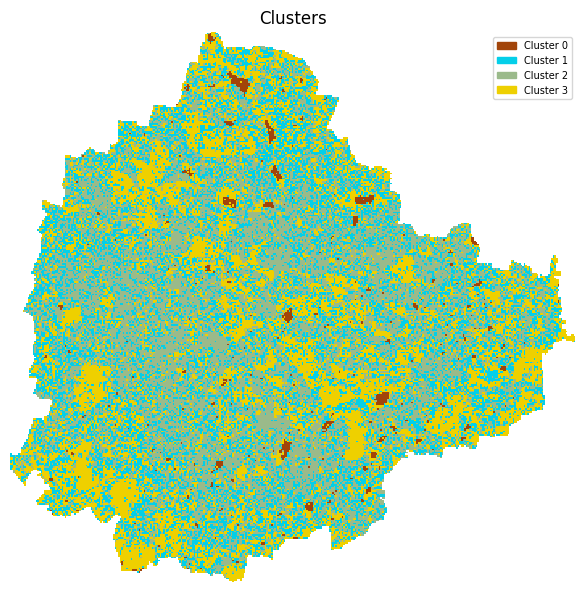

In [98]:
# Random distinct colors for each cluster
rng_colors = np.random.default_rng(0)
cluster_colors = rng_colors.random((n_clusters, 3))
cmap_clusters = mcolors.ListedColormap(cluster_colors)
preview_clusters = clustered.rio.reproject(clustered.rio.crs, resolution=100)


fig, ax = plt.subplots(1, 1)
fig.set_size_inches(6, 6)

preview_clusters.plot.imshow(
    ax=ax,
    cmap=cmap_clusters,
    vmin=-0.5, vmax=n_clusters - 0.5,
    add_colorbar=False)
# Add cluster number labels to legend
handles = [mpatches.Patch(color=cluster_colors[c], label=f'Cluster {c}') for c in range(n_clusters)]
ax.legend(handles=handles, loc='upper right', fontsize=7)
ax.set_title('Clusters')
ax.set_axis_off()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### Identify the Water Cluster

We compute the mean MNDWI for every cluster. Water bodies have distinctively high MNDWI values (typically > 0), so the cluster with the highest mean MNDWI is the water cluster.

In [ ]:
mndwi_da = composite['mndwi']

# Group MNDWI by cluster label and compute mean per cluster
cluster_mndwi_mean = mndwi_da.groupby(clustered).mean()

In [ ]:
%%time
cluster_mndwi_mean = cluster_mndwi_mean.compute()

In [ ]:
water_cluster = int(cluster_mndwi_mean.idxmax())

print('Mean MNDWI per cluster:')
for label, value in zip(cluster_mndwi_mean.cluster.values, cluster_mndwi_mean.values):
    marker = ' <-- water' if label == water_cluster else ''
    print(f'  Cluster {int(label)}: {float(value):+.4f}{marker}')

print(f'\nWater cluster: {water_cluster}')

Select all pixels belonging to the water cluster.

In [ ]:
water_mask = (clustered == water_cluster).astype('float32')
water_mask = water_mask.where(~np.isnan(clustered))
water_mask = water_mask.rio.write_nodata(np.nan)
water_mask

### Visualize Results

Plot the RGB composite, the full cluster map, and the extracted water mask side by side.

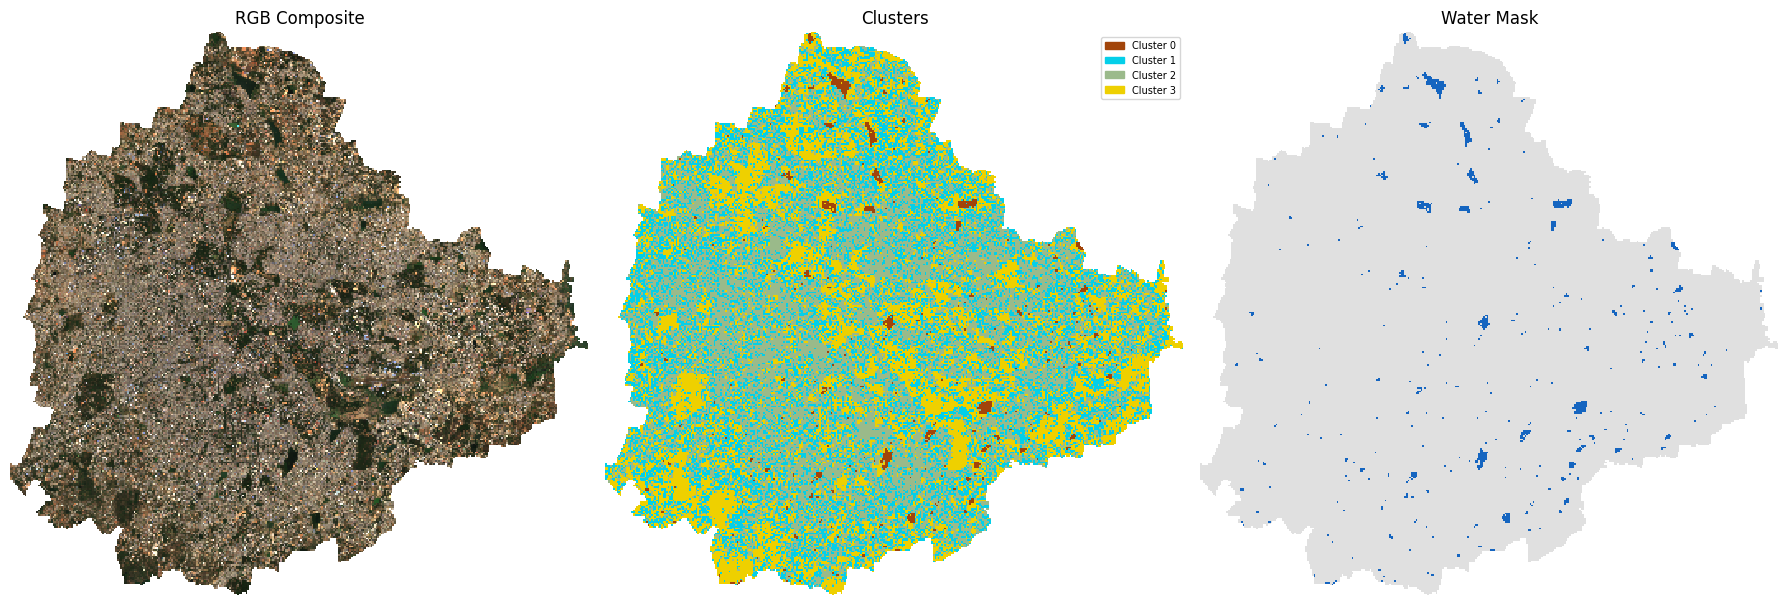

In [97]:
# Random distinct colors for each cluster
rng_colors = np.random.default_rng(0)
cluster_colors = rng_colors.random((n_clusters, 3))
cmap_clusters = mcolors.ListedColormap(cluster_colors)

# Low-resolution previews
preview_rgb = composite[['red', 'green', 'blue']].to_array('band').rio.reproject(
    composite.rio.crs, resolution=100)
preview_clusters = clustered.rio.reproject(clustered.rio.crs, resolution=100)
preview_water    = water_mask.rio.reproject(water_mask.rio.crs, resolution=100)

fig, axes = plt.subplots(1, 3)
fig.set_size_inches(18, 6)

preview_rgb.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=axes[0], vmin=0, vmax=0.3)
axes[0].set_title('RGB Composite')

preview_clusters.plot.imshow(
    ax=axes[1],
    cmap=cmap_clusters,
    vmin=-0.5, vmax=n_clusters - 0.5,
    add_colorbar=False)
# Add cluster number labels to legend
handles = [mpatches.Patch(color=cluster_colors[c], label=f'Cluster {c}') for c in range(n_clusters)]
axes[1].legend(handles=handles, loc='upper right', fontsize=7)
axes[1].set_title('Clusters')

water_cmap = mcolors.ListedColormap(['#e0e0e0', '#1565C0'])
preview_water.plot.imshow(
    ax=axes[2],
    cmap=water_cmap,
    vmin=0, vmax=1,
    add_colorbar=False)
axes[2].set_title('Water Mask')

for ax in axes:
    ax.set_axis_off()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### Save the Water Mask

Save the result as a Cloud-Optimized GeoTIFF to the configured output folder.

In [ ]:
output_file = f'water_mask_{n_clusters}.tif'
output_path = os.path.join(output_folder, output_file)
water_mask.rio.to_raster(output_path, driver='COG')
print(f'Saved {output_path}')

### Exercise

Instead of manually specifying the number of clusters used, we can determine the optimal number clusters. There are variety of methods available for selecting clusters. See all available metrics at [Clustering performance evaluation](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation).

The cells below have an implementation of one of the metrics named **Silhouette Score**. It measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The Silhouette score ranges from -1 to +1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. If most objects have a high value, then the clustering configuration is appropriate. The optimal number of clusters is typically the one that maximizes the average Silhouette score.

Select the optimal number of clusters and export the resulting water mask. Evaluate and compare the results.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

min_clusters = 2 # need a minimum of 2 clusters
max_clusters = 10
for i in range(min_clusters, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(sample)
    score = silhouette_score(sample, cluster_labels)
    silhouette_scores.append(score)

silhouette_scores

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(min_clusters, max_clusters + 1), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()